# Paper-style β-VAE adapted to PROPHESY C1s spectra

This notebook implements the fully connected β-VAE described in *Unsupervised real-world knowledge extraction via disentangled variational autoencoders for photon diagnostics*, adapted to the PROPHESY-generated Excel files.

The paper used `14000 → 2824 → 579 → 117 → 24 → 12`, where the 24 encoder outputs represent 12 means and 12 log-variances. PROPHESY C1s spectra contain 401 points, so the corresponding network used here is `401 → 256 → 128 → 64 → 24 → 12`, with the mirrored decoder `12 → 64 → 128 → 256 → 401`. The VAE architecture itself is unchanged from the previous notebook: twelve latent variables, fully connected layers, Mish activations, a sigmoid output, and the β-weighted KL objective.

Peak parameters are **not used for training**. They are retained only to test whether physical properties emerge in the latent space. PROPHESY's noise-free `Stot` is used as the reconstruction target while `Snoisy` remains the input, preventing the network from being rewarded for reproducing Poisson noise.

## Requirements

Use a Python environment containing PyTorch, NumPy, OpenPyXL, and Matplotlib. If necessary, install them in the active notebook kernel with:

```python
%pip install torch numpy openpyxl matplotlib
```

The cell is shown as documentation rather than executed automatically so the notebook does not modify your environment without permission.

In [1]:
from pathlib import Path
import copy
import json
import math
import random
import time

import matplotlib.pyplot as plt
import numpy as np
from openpyxl import load_workbook
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__}; device={DEVICE}")

PyTorch 2.6.0; device=cpu


In [2]:
# Prefer the current shared workspace. On another server, set the override to that
# server's PROPHESY directory or leave it as None to use the sibling-directory fallback.
PROPHESY_ROOT_OVERRIDE = Path("/home/umar/projects/Thesis/PROPHESY")
prophesy_candidates = [
    PROPHESY_ROOT_OVERRIDE,
    (Path.cwd() / "../PROPHESY").resolve(),
    Path("/home/umar/thesis/PROPHESY"),
]
PROPHESY_ROOT = next((p for p in prophesy_candidates if p is not None and (p / "data").exists()), None)
if PROPHESY_ROOT is None:
    raise FileNotFoundError("Set PROPHESY_ROOT to the PROPHESY project directory.")

DATA_ROOT = PROPHESY_ROOT / "data"
CACHE_DIR = Path.cwd() / "data_cache"
OUTPUT_DIR = Path.cwd() / "outputs" / "prophesy_beta_vae"
CACHE_FILE = CACHE_DIR / "prophesy_c1s_401.npz"
CHECKPOINT_FILE = OUTPUT_DIR / "best_beta_vae.pt"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_LENGTH = 401
REBUILD_CACHE = False  # Set True only to force rebuilding an otherwise current cache.
all_workbooks = list(DATA_ROOT.rglob("data.xlsx"))
model_workbooks = [p for p in all_workbooks if "s2p" not in {part.lower() for part in p.parts}
                   and "water" not in {part.lower() for part in p.parts}]
print(f"PROPHESY data: {DATA_ROOT}")
print(f"Discovered workbooks: {len(all_workbooks)} total; {len(model_workbooks)} eligible C1s/non-water")
print(f"Cache: {CACHE_FILE}")

PROPHESY data: /home/umar/thesis/PROPHESY/data
Discovered workbooks: 214 total; 136 eligible C1s/non-water
Cache: /home/umar/thesis/Conditional_VAE/data_cache/prophesy_c1s_401.npz


## Extract compatible PROPHESY spectra

Each `Snoisy` or `Snoisy_*` column becomes one sample. The extractor keeps only non-water, non-S2p C1s sheets with 401 binding-energy points and a common energy axis. It also stores the simulated clean signal, background, expected total signal, photon energy, and three true peak components.

The workbook's parent directory becomes `case_id`. All spectra from the same case will remain in one train/validation/test partition, preventing repeated noise realizations of the same physical spectrum from leaking between partitions. A manifest of workbook paths, sizes, and modification times is stored with the cache, so adding or changing PROPHESY workbooks automatically rebuilds the extracted dataset on the next fresh notebook run.

In [3]:
def _column(headers, name):
    return headers.index(name) if name in headers else None


def extract_prophesy_c1s(data_root: Path, target_length: int = 401):
    noisy_parts, clean_parts, background_parts, total_parts = [], [], [], []
    centers_parts, widths_parts, fractions_parts = [], [], []
    photon_energy_parts, case_parts, source_parts, sweep_parts = [], [], [], []
    reference_axis = None
    skipped_axis = 0
    skipped_incomplete = 0

    workbook_paths = sorted(data_root.rglob("data.xlsx"))
    for workbook_path in workbook_paths:
        # Start with one chemically consistent family and one fixed grid.
        lower_parts = {part.lower() for part in workbook_path.parts}
        if "s2p" in lower_parts or "water" in lower_parts:
            continue

        case_id = str(workbook_path.parent.relative_to(data_root))
        workbook = load_workbook(workbook_path, read_only=True, data_only=True)
        sheet_names = set(workbook.sheetnames)

        for sheet_name in workbook.sheetnames:
            if not sheet_name.startswith("hν_"):
                continue
            ws = workbook[sheet_name]
            if ws.max_row - 1 != target_length:
                continue

            headers = [cell.value for cell in next(ws.iter_rows(min_row=1, max_row=1))]
            required = {"Be", "Snoisy", "SpectrumA_1", "Sbg", "Stot", "hν"}
            if not required.issubset(set(headers)):
                skipped_incomplete += 1
                continue

            rows = list(ws.iter_rows(min_row=2, values_only=True))
            block = np.asarray(rows, dtype=np.float64)
            axis = block[:, _column(headers, "Be")].astype(np.float32)
            if reference_axis is None:
                reference_axis = axis
            elif not np.allclose(axis, reference_axis, rtol=0.0, atol=1e-6):
                skipped_axis += 1
                continue

            noise_indices = [
                i for i, name in enumerate(headers)
                if name == "Snoisy" or (isinstance(name, str) and name.startswith("Snoisy_"))
            ]
            if not noise_indices:
                continue

            noisy = block[:, noise_indices].T.astype(np.float32)
            n_samples = noisy.shape[0]
            clean = block[:, _column(headers, "SpectrumA_1")].astype(np.float32)
            background = block[:, _column(headers, "Sbg")].astype(np.float32)
            expected_total = block[:, _column(headers, "Stot")].astype(np.float32)
            photon_energy = float(block[0, _column(headers, "hν")])

            meta_name = f"meta_{sheet_name}"
            if meta_name not in sheet_names:
                skipped_incomplete += 1
                continue
            meta_ws = workbook[meta_name]
            meta_headers = [cell.value for cell in next(meta_ws.iter_rows(min_row=1, max_row=1))]
            meta_rows = np.asarray(
                list(meta_ws.iter_rows(min_row=2, values_only=True)), dtype=np.float64
            )
            if meta_rows.ndim != 2 or meta_rows.shape[0] < 3:
                skipped_incomplete += 1
                continue
            centers = meta_rows[:3, _column(meta_headers, "peak_mode")].astype(np.float32)
            widths = meta_rows[:3, _column(meta_headers, "peak_width")].astype(np.float32)
            fractions = meta_rows[:3, _column(meta_headers, "peak_probability")].astype(np.float32)

            noisy_parts.append(noisy)
            clean_parts.append(np.repeat(clean[None, :], n_samples, axis=0))
            background_parts.append(np.repeat(background[None, :], n_samples, axis=0))
            total_parts.append(np.repeat(expected_total[None, :], n_samples, axis=0))
            centers_parts.append(np.repeat(centers[None, :], n_samples, axis=0))
            widths_parts.append(np.repeat(widths[None, :], n_samples, axis=0))
            fractions_parts.append(np.repeat(fractions[None, :], n_samples, axis=0))
            photon_energy_parts.append(np.full(n_samples, photon_energy, dtype=np.float32))
            case_parts.extend([case_id] * n_samples)
            source_parts.extend([f"{workbook_path.relative_to(data_root)}::{sheet_name}"] * n_samples)
            sweep_parts.extend([str(headers[i]) for i in noise_indices])

        workbook.close()

    if not noisy_parts:
        raise RuntimeError("No compatible 401-point C1s spectra were found.")

    result = {
        "axis": reference_axis,
        "noisy": np.concatenate(noisy_parts),
        "clean": np.concatenate(clean_parts),
        "background": np.concatenate(background_parts),
        "expected_total": np.concatenate(total_parts),
        "peak_center": np.concatenate(centers_parts),
        "peak_width": np.concatenate(widths_parts),
        "peak_fraction": np.concatenate(fractions_parts),
        "photon_energy": np.concatenate(photon_energy_parts),
        "case_id": np.asarray(case_parts),
        "source": np.asarray(source_parts),
        "sweep": np.asarray(sweep_parts),
    }
    print(f"Skipped {skipped_axis} sheets with a different axis.")
    print(f"Skipped {skipped_incomplete} incomplete sheets.")
    return result

In [4]:
def workbook_manifest(data_root):
    records = []
    for path in sorted(data_root.rglob("data.xlsx")):
        lower_parts = {part.lower() for part in path.parts}
        if "s2p" in lower_parts or "water" in lower_parts:
            continue
        stat = path.stat()
        records.append(f"{path.relative_to(data_root)}|{stat.st_size}|{stat.st_mtime_ns}")
    return np.asarray(records, dtype=np.str_)

current_manifest = workbook_manifest(DATA_ROOT)
cache_is_current = False
if CACHE_FILE.exists() and not REBUILD_CACHE:
    with np.load(CACHE_FILE, allow_pickle=False) as cached:
        cache_is_current = ("workbook_manifest" in cached.files and
                            np.array_equal(cached["workbook_manifest"], current_manifest))

if not cache_is_current:
    dataset = extract_prophesy_c1s(DATA_ROOT, TARGET_LENGTH)
    np.savez_compressed(CACHE_FILE, **dataset, workbook_manifest=current_manifest)
    print(f"Saved {CACHE_FILE}")
else:
    with np.load(CACHE_FILE, allow_pickle=False) as cached:
        dataset = {name: cached[name] for name in cached.files if name != "workbook_manifest"}
    print(f"Loaded {CACHE_FILE}")

print(f"Spectra: {dataset['noisy'].shape}")
print(f"Independent cases: {np.unique(dataset['case_id']).size}")
print(f"Independent physical spectra: {np.unique(dataset['source']).size}")
print(f"Photon-energy range: {dataset['photon_energy'].min():.1f}–{dataset['photon_energy'].max():.1f} eV")
print(f"Count range: {dataset['noisy'].min():.1f}–{dataset['noisy'].max():.1f}")

# Preflight: repeated noisy sweeps do not add new physical conditions.
_, representative_idx = np.unique(dataset["source"], return_index=True)
preflight_features = {
    "photon energy": dataset["photon_energy"][representative_idx],
    **{f"peak {i + 1} center": dataset["peak_center"][representative_idx, i] for i in range(3)},
    **{f"peak {i + 1} width": dataset["peak_width"][representative_idx, i] for i in range(3)},
    **{f"peak {i + 1} fraction": dataset["peak_fraction"][representative_idx, i] for i in range(3)},
    "log total area": np.log1p(dataset["expected_total"][representative_idx].sum(axis=1)),
    "log background area": np.log1p(dataset["background"][representative_idx].sum(axis=1)),
}
constant_features = []
print("\nPhysical-condition variation (rounded unique values):")
for name, values in preflight_features.items():
    unique_count = np.unique(np.round(values, 6)).size
    print(f"  {name:<24} {unique_count:5d}")
    if unique_count < 2:
        constant_features.append(name)
if constant_features:
    print("WARNING: constant variables cannot be learned independently:", constant_features)

varying_names = [name for name, values in preflight_features.items() if np.ptp(values) > 1e-6]
varying_values = np.column_stack([preflight_features[name] for name in varying_names])
feature_correlation = np.corrcoef(varying_values, rowvar=False)
strong_pairs = []
for i in range(len(varying_names)):
    for j in range(i + 1, len(varying_names)):
        if abs(feature_correlation[i, j]) >= 0.98:
            strong_pairs.append((varying_names[i], varying_names[j], feature_correlation[i, j]))
if strong_pairs:
    print("WARNING: strongly coupled physical variables (|r| >= 0.98):")
    for left, right, value in strong_pairs:
        print(f"  {left} / {right}: r={value:+.3f}")

_, sweeps_per_source = np.unique(dataset["source"], return_counts=True)
print(f"Noisy sweeps per physical spectrum: min={sweeps_per_source.min()}, "
      f"median={np.median(sweeps_per_source):.0f}, max={sweeps_per_source.max()}")

Skipped 0 sheets with a different axis.
Skipped 0 incomplete sheets.
Saved /home/umar/thesis/Conditional_VAE/data_cache/prophesy_c1s_401.npz
Spectra: (47020, 401)
Independent cases: 124
Independent physical spectra: 1020
Photon-energy range: 650.0–1884.0 eV
Count range: 0.0–148100.0

Physical-condition variation (rounded unique values):
  photon energy               31
  peak 1 center               31
  peak 2 center               31
  peak 3 center               31
  peak 1 width                31
  peak 2 width                31
  peak 3 width                31
  peak 1 fraction              1
  peak 2 fraction              1
  peak 3 fraction              1
  log total area             940
  log background area        939
  photon energy / peak 1 width: r=+1.000
  photon energy / peak 2 width: r=+1.000
  photon energy / peak 3 width: r=+1.000
  peak 1 center / peak 2 center: r=+1.000
  peak 1 center / peak 3 center: r=+1.000
  peak 2 center / peak 3 center: r=+1.000
  peak 1 width /

## Leakage-safe split and normalization

Splitting is performed by physical case rather than spectrum. Repeated noisy acquisitions from one simulated condition therefore cannot appear in both training and testing. Candidate group splits are scored for both the means and spreads of photon energy, intensity, background, peak position, and peak width, as well as sample/source counts. This is important for the expanded PROPHESY dataset, whose intensity spans more than three orders of magnitude.

PROPHESY stores Poisson-like non-negative counts with a much wider dynamic range than the paper's 8-bit ADC values. The notebook therefore uses the variance-stabilizing Anscombe transform `2√(x + 3/8)`, scaled from training data into `[0, 1]`. Its inverse is quadratic rather than exponential, so small decoder errors are no longer magnified into extreme raw-count errors. Training batches use inverse-frequency sampling by physical spectrum (`source`) and a fixed number of draws per source per epoch. Thus fifty repeated sweeps improve denoising without making one simulated condition dominate or doubling training time whenever more sweeps are added.

In [5]:
all_cases = np.unique(dataset["case_id"])
case_ids = dataset["case_id"]
n_cases = len(all_cases)
n_test = max(1, int(round(0.15 * n_cases)))
n_val = max(1, int(round(0.15 * n_cases)))

# Describe each physical case using one row per physical spectrum, not repeated sweeps.
case_features = []
case_source_counts = []
case_sample_counts = []
for case in all_cases:
    sample_idx = np.flatnonzero(case_ids == case)
    source_idx = representative_idx[case_ids[representative_idx] == case]
    log_area = np.log1p(dataset["expected_total"][source_idx].sum(axis=1))
    log_background = np.log1p(dataset["background"][source_idx].sum(axis=1))
    case_features.append(np.concatenate([
        [np.mean(dataset["photon_energy"][source_idx])],
        np.quantile(log_area, [0.10, 0.50, 0.90]),
        np.quantile(log_background, [0.10, 0.50, 0.90]),
        np.mean(dataset["peak_center"][source_idx], axis=0),
        np.mean(dataset["peak_width"][source_idx], axis=0),
    ]))
    case_source_counts.append(len(source_idx))
    case_sample_counts.append(len(sample_idx))
case_features = np.asarray(case_features, dtype=np.float64)
case_source_counts = np.asarray(case_source_counts, dtype=np.float64)
case_sample_counts = np.asarray(case_sample_counts, dtype=np.float64)
case_features = (case_features - case_features.mean(axis=0)) / np.maximum(case_features.std(axis=0), 1e-8)

# Search reproducibly for group splits whose distributions resemble the complete dataset.
rng = np.random.default_rng(SEED)
best_score, best_partition = np.inf, None
target_holdout_share = n_test / n_cases
def partition_error(case_indices):
    selected = case_features[case_indices]
    moment_error = np.mean(np.abs(selected.mean(axis=0)))
    spread_error = np.mean(np.abs(selected.std(axis=0) - 1.0))
    source_share = case_source_counts[case_indices].sum() / case_source_counts.sum()
    sample_share = case_sample_counts[case_indices].sum() / case_sample_counts.sum()
    return moment_error + 0.5 * spread_error + 2.0 * abs(source_share - target_holdout_share) + abs(sample_share - target_holdout_share)

for _ in range(10000):
    order = rng.permutation(n_cases)
    test_case_idx = order[:n_test]
    val_case_idx = order[n_test:n_test + n_val]
    score = partition_error(test_case_idx) + partition_error(val_case_idx)
    if score < best_score:
        best_score = score
        best_partition = (test_case_idx.copy(), val_case_idx.copy(), order[n_test + n_val:].copy())
test_case_idx, val_case_idx, train_case_idx = best_partition
test_cases = set(all_cases[test_case_idx])
val_cases = set(all_cases[val_case_idx])
train_cases = set(all_cases[train_case_idx])
train_idx = np.flatnonzero(np.isin(case_ids, list(train_cases)))
val_idx = np.flatnonzero(np.isin(case_ids, list(val_cases)))
test_idx = np.flatnonzero(np.isin(case_ids, list(test_cases)))
assert train_cases.isdisjoint(val_cases | test_cases)
assert val_cases.isdisjoint(test_cases)

def anscombe(x):
    return 2.0 * np.sqrt(np.maximum(x, 0.0) + 3.0 / 8.0)

# Five percent headroom prevents saturation at the largest training count.
TRANSFORM_SCALE = 1.05 * float(anscombe(dataset["expected_total"][train_idx]).max())
if not np.isfinite(TRANSFORM_SCALE) or TRANSFORM_SCALE <= 0:
    raise ValueError("Invalid Anscombe normalization scale.")

def normalize_counts(x):
    return np.clip(anscombe(x) / TRANSFORM_SCALE, 0.0, 1.0).astype(np.float32)

def denormalize_counts(x):
    transformed = np.clip(x, 0.0, 1.0) * TRANSFORM_SCALE
    return np.maximum((transformed / 2.0) ** 2 - 3.0 / 8.0, 0.0)

x_all = normalize_counts(dataset["noisy"])
target_all = normalize_counts(dataset["expected_total"])

BATCH_SIZE = 512 if torch.cuda.is_available() else 256
TRAIN_DRAWS_PER_SOURCE = 12

def make_loader(indices, training=False):
    tensors = TensorDataset(torch.from_numpy(x_all[indices]), torch.from_numpy(target_all[indices]))
    sampler = None
    if training:
        sources = dataset["source"][indices]
        unique_sources, source_counts = np.unique(sources, return_counts=True)
        count_by_source = dict(zip(unique_sources.tolist(), source_counts.tolist()))
        weights = torch.as_tensor([1.0 / count_by_source[s] for s in sources], dtype=torch.double)
        epoch_samples = min(len(indices), TRAIN_DRAWS_PER_SOURCE * len(unique_sources))
        sampler_generator = torch.Generator().manual_seed(SEED)
        sampler = WeightedRandomSampler(
            weights, num_samples=epoch_samples, replacement=True, generator=sampler_generator
        )
    return DataLoader(
        tensors, batch_size=BATCH_SIZE, shuffle=False, sampler=sampler, num_workers=0,
        pin_memory=torch.cuda.is_available(), drop_last=False,
    )

train_loader = make_loader(train_idx, training=True)
val_loader = make_loader(val_idx)
test_loader = make_loader(test_idx)
print(f"train={len(train_idx):,}, validation={len(val_idx):,}, test={len(test_idx):,}")
print(f"train cases={len(train_cases)}, validation cases={len(val_cases)}, test cases={len(test_cases)}")
print(f"train physical spectra={np.unique(dataset['source'][train_idx]).size:,}; "
      f"balanced draws/epoch={len(train_loader.sampler):,}; batch size={BATCH_SIZE}")
print(f"balanced group-split score={best_score:.4f}")
print(f"Anscombe normalization scale={TRANSFORM_SCALE:.4f}")

train=32,710, validation=7,155, test=7,155
train cases=86, validation cases=19, test cases=19
train physical spectra=710; balanced draws/epoch=8,520; batch size=256
balanced group-split score=0.0772
Anscombe normalization scale=754.7658


## β-VAE architecture

The final encoder layer produces 24 values, split into twelve-dimensional `mu` and `logvar`. The decoder mirrors the encoder but excludes that distribution-parameter layer, as in the paper.

In [6]:
class BetaVAE(nn.Module):
    def __init__(self, input_dim=401, latent_dim=12):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256), nn.Mish(),
            nn.Linear(256, 128), nn.Mish(),
            nn.Linear(128, 64), nn.Mish(),
        )
        self.latent_statistics = nn.Linear(64, 2 * latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.Mish(),
            nn.Linear(64, 128), nn.Mish(),
            nn.Linear(128, 256), nn.Mish(),
            nn.Linear(256, input_dim), nn.Sigmoid(),
        )
        self.apply(self._initialize)

    @staticmethod
    def _initialize(module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            nn.init.zeros_(module.bias)

    def encode(self, x):
        statistics = self.latent_statistics(self.encoder(x))
        return statistics.chunk(2, dim=-1)

    @staticmethod
    def reparameterize(mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

model = BetaVAE(input_dim=TARGET_LENGTH, latent_dim=12).to(DEVICE)
print(model)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

BetaVAE(
  (encoder): Sequential(
    (0): Linear(in_features=401, out_features=256, bias=True)
    (1): Mish()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): Mish()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): Mish()
  )
  (latent_statistics): Linear(in_features=64, out_features=24, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=12, out_features=64, bias=True)
    (1): Mish()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): Mish()
    (4): Linear(in_features=128, out_features=256, bias=True)
    (5): Mish()
    (6): Linear(in_features=256, out_features=401, bias=True)
    (7): Sigmoid()
  )
)
Trainable parameters: 290,857


## Training

The VAE architecture remains the paper-style network above. The reconstruction objective is adapted to the known PROPHESY noise model: noisy counts are encoded, while the decoder is compared with the noise-free expected spectrum. Pointwise and derivative errors are divided by each target spectrum's transformed energy, so the newly added weak spectra are not overwhelmed by high-count spectra. These relative shape terms are supplemented with a robust log-integrated-area loss. The previous maximum-bin peak-height loss remains omitted because it rewards isolated spikes rather than physically broad peaks. β is warmed from zero to the paper's `0.034`, allowing reconstruction to form before enforcing the normal prior. Validation uses the deterministic latent mean, and CUDA training uses automatic mixed precision while all losses remain in float32.

In [7]:
BETA_MAX = 0.034
KL_WARMUP_EPOCHS = 50
EPOCHS = 400
LEARNING_RATE = 3e-4
MIN_LEARNING_RATE = 1e-6
EARLY_STOPPING_PATIENCE = 50
MIN_DELTA = 1e-4
GRADIENT_CLIP_NORM = 5.0
FIRST_DIFFERENCE_WEIGHT = 0.5
SECOND_DIFFERENCE_WEIGHT = 0.1
AREA_WEIGHT = 2.0
SHAPE_ENERGY_FLOOR = 1e-4
USE_AMP = DEVICE.type == "cuda"
if USE_AMP:
    torch.set_float32_matmul_precision("high")

def inverse_anscombe_tensor(x):
    transformed = x.float().clamp(0.0, 1.0) * TRANSFORM_SCALE
    return (((transformed / 2.0) ** 2) - 3.0 / 8.0).clamp_min(0.0)

def beta_vae_loss(reconstruction, target, mu, logvar, beta):
    reconstruction = reconstruction.float()
    target = target.float()
    mu = mu.float()
    logvar = logvar.float()
    target_energy = target.square().sum(dim=1).detach().clamp_min(SHAPE_ENERGY_FLOOR)
    point_loss = ((reconstruction - target).square().sum(dim=1) / target_energy).mean()
    rec_d1 = reconstruction[:, 1:] - reconstruction[:, :-1]
    target_d1 = target[:, 1:] - target[:, :-1]
    first_difference_loss = ((rec_d1 - target_d1).square().sum(dim=1) / target_energy).mean()
    rec_d2 = rec_d1[:, 1:] - rec_d1[:, :-1]
    target_d2 = target_d1[:, 1:] - target_d1[:, :-1]
    second_difference_loss = ((rec_d2 - target_d2).square().sum(dim=1) / target_energy).mean()

    raw_reconstruction = inverse_anscombe_tensor(reconstruction)
    raw_target = inverse_anscombe_tensor(target)
    predicted_area = raw_reconstruction.sum(dim=1).clamp_min(0.0)
    target_area = raw_target.sum(dim=1).clamp_min(0.0)
    area_loss = F.smooth_l1_loss(torch.log1p(predicted_area), torch.log1p(target_area))

    reconstruction_loss = (
        point_loss
        + FIRST_DIFFERENCE_WEIGHT * first_difference_loss
        + SECOND_DIFFERENCE_WEIGHT * second_difference_loss
        + AREA_WEIGHT * area_loss
    )
    kl_loss = (-0.5 * (1 + logvar - mu.square() - logvar.exp())).sum(dim=1).mean()
    total_loss = reconstruction_loss + beta * kl_loss
    return total_loss, reconstruction_loss, kl_loss

@torch.no_grad()
def evaluate(model, loader, beta=BETA_MAX):
    model.eval()
    sums = np.zeros(3, dtype=np.float64)
    count = 0
    for x, target in loader:
        x = x.to(DEVICE, non_blocking=True)
        target = target.to(DEVICE, non_blocking=True)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
            mu, logvar = model.encode(x)
            reconstruction = model.decode(mu)
        values = beta_vae_loss(reconstruction, target, mu, logvar, beta)
        batch_size = x.shape[0]
        sums += np.asarray([v.item() for v in values]) * batch_size
        count += batch_size
    return sums / count

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-6)
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=10, threshold=MIN_DELTA, min_lr=MIN_LEARNING_RATE
)
history = {"train_total": [], "train_reconstruction": [], "train_kl": [],
           "val_total": [], "val_reconstruction": [], "val_kl": [], "lr": [], "beta": []}
best_val = math.inf
best_state = None
epochs_without_improvement = 0
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    beta = BETA_MAX * min(1.0, epoch / KL_WARMUP_EPOCHS)
    model.train()
    sums = np.zeros(3, dtype=np.float64)
    count = 0
    for x, target in train_loader:
        x = x.to(DEVICE, non_blocking=True)
        target = target.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
            reconstruction, mu, logvar = model(x)
            loss, reconstruction_loss, kl_loss = beta_vae_loss(reconstruction, target, mu, logvar, beta)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()
        batch_size = x.shape[0]
        sums += np.asarray([loss.item(), reconstruction_loss.item(), kl_loss.item()]) * batch_size
        count += batch_size

    train_values = sums / count
    val_values = evaluate(model, val_loader, beta=BETA_MAX)
    history["train_total"].append(train_values[0])
    history["train_reconstruction"].append(train_values[1])
    history["train_kl"].append(train_values[2])
    history["val_total"].append(val_values[0])
    history["val_reconstruction"].append(val_values[1])
    history["val_kl"].append(val_values[2])
    history["lr"].append(optimizer.param_groups[0]["lr"])
    history["beta"].append(beta)

    improved = val_values[0] < best_val - MIN_DELTA
    if improved:
        best_val = float(val_values[0])
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
        torch.save({
            "model_state_dict": best_state,
            "input_dim": TARGET_LENGTH, "latent_dim": 12, "beta": BETA_MAX,
            "loss_weights": {"first_difference": FIRST_DIFFERENCE_WEIGHT,
                             "second_difference": SECOND_DIFFERENCE_WEIGHT,
                             "log_area": AREA_WEIGHT,
                             "shape_energy_floor": SHAPE_ENERGY_FLOOR},
            "batch_size": BATCH_SIZE, "train_draws_per_source": TRAIN_DRAWS_PER_SOURCE,
            "transform": "anscombe", "transform_scale": TRANSFORM_SCALE, "seed": SEED,
            "workbook_manifest": current_manifest.tolist(),
            "train_cases": sorted(train_cases),
            "validation_cases": sorted(val_cases),
            "test_cases": sorted(test_cases),
        }, CHECKPOINT_FILE)
    else:
        epochs_without_improvement += 1

    scheduler.step(val_values[0])
    if epoch == 1 or epoch % 10 == 0:
        print(
            f"epoch {epoch:03d} | train={train_values[0]:.4f} "
            f"(rec={train_values[1]:.4f}, kl={train_values[2]:.4f}) | "
            f"val={val_values[0]:.4f} | β={beta:.4f} | lr={history['lr'][-1]:.2e}"
        )
    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

if best_state is None:
    raise RuntimeError("Training produced no finite validation checkpoint.")
model.load_state_dict(best_state)
print(f"Best validation loss: {best_val:.4f}")
print(f"Training time: {(time.time() - start_time) / 60:.1f} minutes")
print(f"Checkpoint: {CHECKPOINT_FILE}")

epoch 001 | train=1008.1930 (rec=1008.1912, kl=2.6178) | val=835.0614 | β=0.0007 | lr=3.00e-04
epoch 010 | train=1.8407 (rec=1.6245, kl=31.7821) | val=1.5623 | β=0.0068 | lr=3.00e-04
epoch 020 | train=0.3400 (rec=0.1613, kl=13.1399) | val=0.5530 | β=0.0136 | lr=3.00e-04
epoch 030 | train=0.3291 (rec=0.1510, kl=8.7292) | val=0.4086 | β=0.0204 | lr=3.00e-04
epoch 040 | train=0.3365 (rec=0.1545, kl=6.6924) | val=0.3420 | β=0.0272 | lr=3.00e-04
epoch 050 | train=0.3338 (rec=0.1520, kl=5.3473) | val=0.3049 | β=0.0340 | lr=3.00e-04
epoch 060 | train=0.3050 (rec=0.1463, kl=4.6693) | val=0.2779 | β=0.0340 | lr=3.00e-04
epoch 070 | train=0.2810 (rec=0.1418, kl=4.0927) | val=0.2540 | β=0.0340 | lr=3.00e-04
epoch 080 | train=0.2655 (rec=0.1420, kl=3.6323) | val=0.2401 | β=0.0340 | lr=3.00e-04
epoch 090 | train=0.2506 (rec=0.1389, kl=3.2862) | val=0.2261 | β=0.0340 | lr=3.00e-04
epoch 100 | train=0.2372 (rec=0.1366, kl=2.9589) | val=0.2160 | β=0.0340 | lr=3.00e-04
epoch 110 | train=0.2259 (rec=0.1

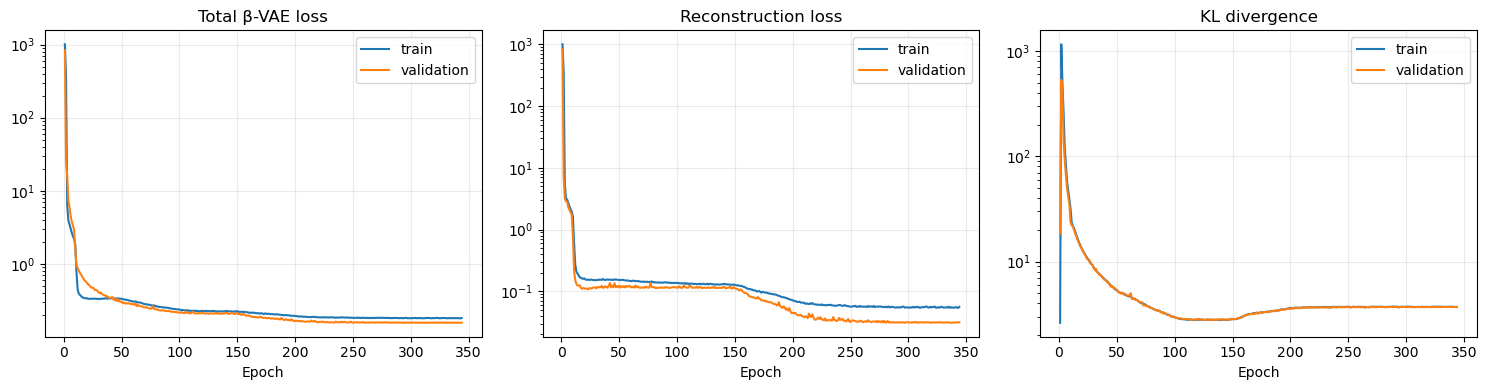

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs = np.arange(1, len(history["train_total"]) + 1)
for ax, key, title in zip(
    axes, ["total", "reconstruction", "kl"],
    ["Total β-VAE loss", "Reconstruction loss", "KL divergence"],
):
    ax.plot(epochs, history[f"train_{key}"], label="train")
    ax.plot(epochs, history[f"val_{key}"], label="validation")
    ax.set(title=title, xlabel="Epoch")
    ax.set_yscale("log")
    ax.grid(alpha=0.25)
    ax.legend()
plt.tight_layout()
plt.show()

## Reconstruction and denoising check

The grey line is a noisy simulated acquisition, black is the deterministic VAE reconstruction obtained from the latent mean, and orange is PROPHESY's noise-free expected total signal. Training maps the grey input to the orange target. Metrics are reported in both transformed space and raw-count space. Peak-height and peak-position errors are calculated after subtracting PROPHESY's known background from both reconstruction and target; taking the maximum of the total spectrum was misleading for weak spectra whose rising background exceeded the actual photoelectron peak. Source-balanced summaries prevent conditions with many noisy sweeps from dominating the report.

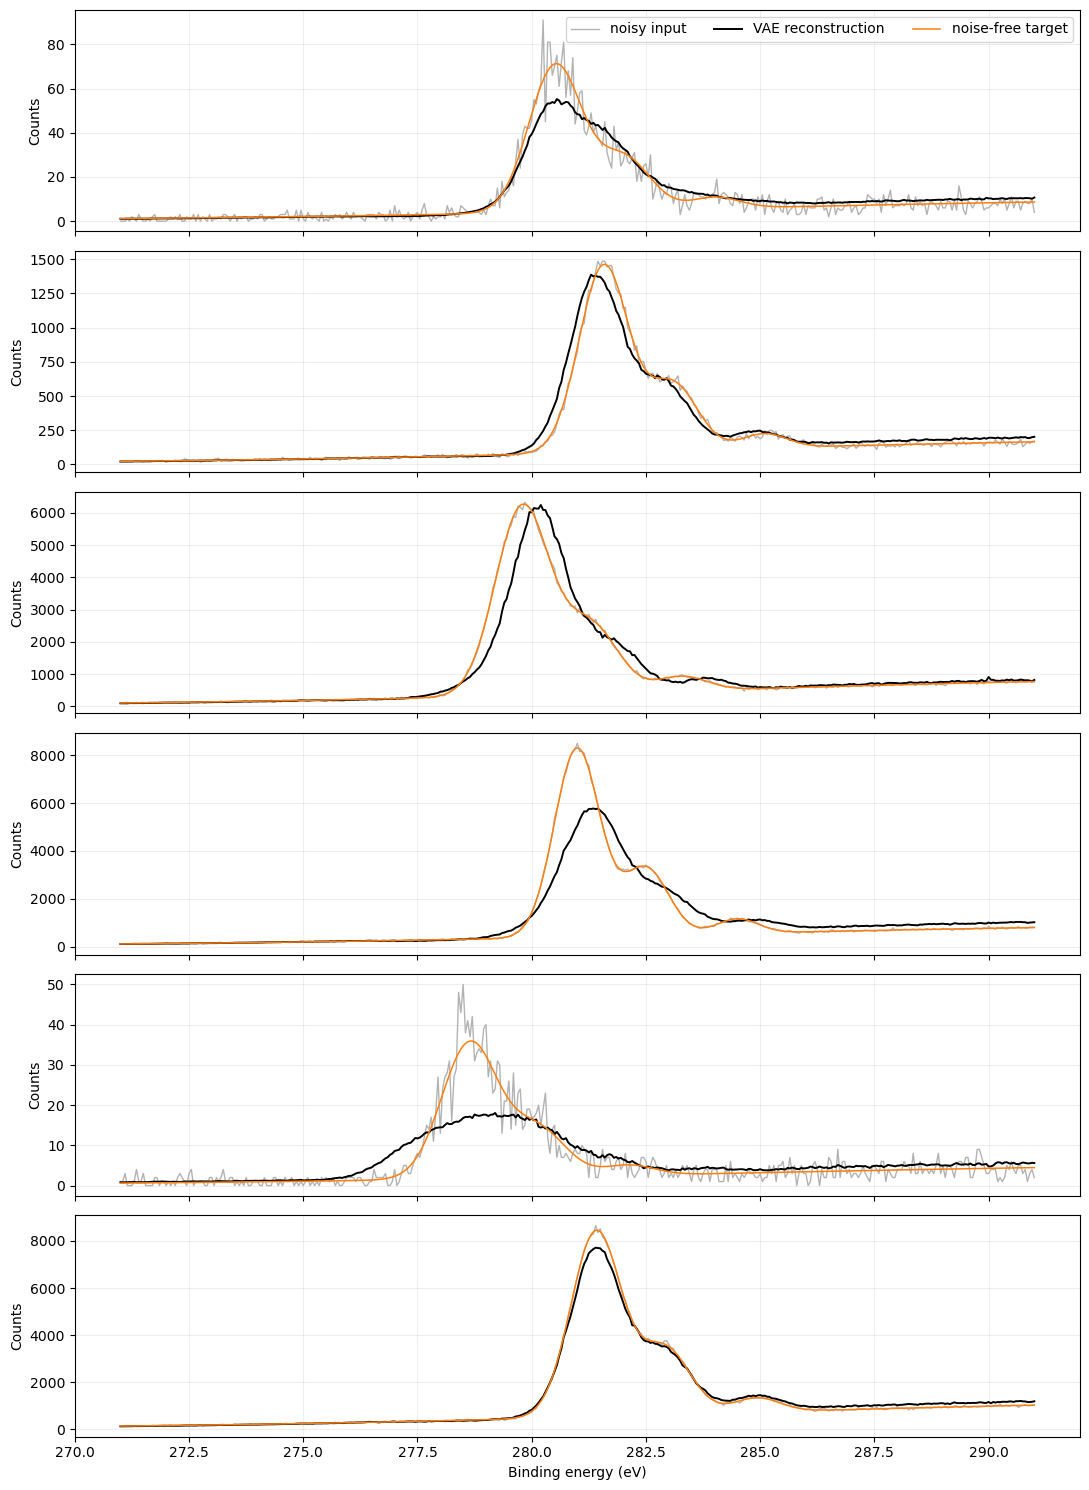

Test total=0.1620, reconstruction=0.0324, KL=3.8114
Anscombe-space MSE: 0.000132
Per-spectrum NRMSE                      p50= 0.0522  p90= 0.1472  p95= 0.5025
Integrated-area relative error          p50=  2.42%  p90=  5.69%  p95=  6.92%
Peak-height relative error              p50= 16.00%  p90= 47.80%  p95=339.76%
Dominant-peak position error            p50= 0.1500 eV  p90= 0.5000 eV  p95= 0.8500 eV

Source-balanced medians across 155 physical spectra:
  NRMSE=0.0513; area=2.32%; peak=14.41%; position=0.1500 eV

Metrics by target integrated-intensity quintile:
 band      n    median NRMSE    median area error    median peak error
 Q1     1431          0.0597               2.16%               22.79%
 Q2     1335          0.0822               1.82%               12.87%
 Q3     1482          0.0453               3.68%               12.24%
 Q4     1428          0.0538               2.28%               21.16%
 Q5     1479          0.0453               2.61%               13.75%


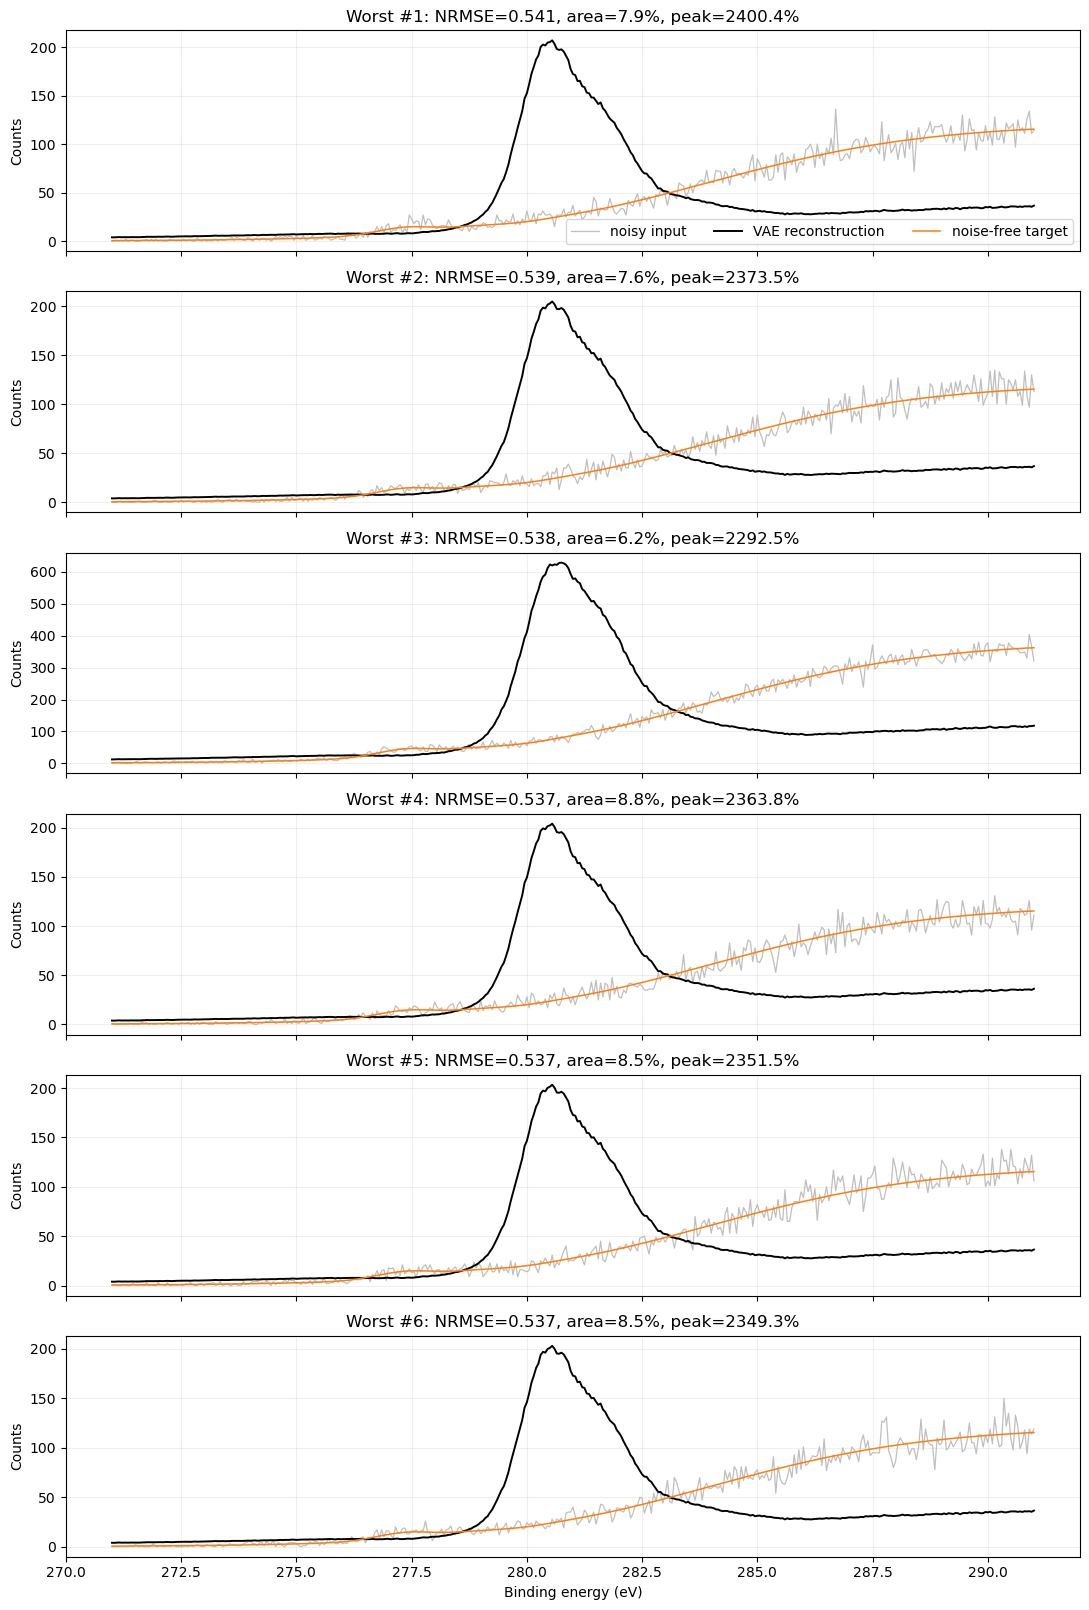

In [9]:
@torch.no_grad()
def reconstruct_from_latent_mean(model, normalized_spectra, batch_size=1024):
    model.eval()
    reconstructed = []
    for start in range(0, len(normalized_spectra), batch_size):
        x = torch.from_numpy(normalized_spectra[start:start + batch_size]).to(DEVICE)
        mu, _ = model.encode(x)
        reconstructed.append(model.decode(mu).cpu().numpy())
    return np.concatenate(reconstructed)

test_reconstruction = reconstruct_from_latent_mean(model, x_all[test_idx])
raw_test_reconstruction = denormalize_counts(test_reconstruction)
raw_test_target = dataset["expected_total"][test_idx]
raw_test_background = dataset["background"][test_idx]
axis = dataset["axis"]

plot_rng = np.random.default_rng(SEED + 1)
example_positions = plot_rng.choice(len(test_idx), size=min(6, len(test_idx)), replace=False)
example_idx = test_idx[example_positions]
fig, axes = plt.subplots(len(example_idx), 1, figsize=(11, 2.5 * len(example_idx)), sharex=True)
axes = np.atleast_1d(axes)
for ax, sample_index, position in zip(axes, example_idx, example_positions):
    ax.plot(axis, dataset["noisy"][sample_index], color="0.70", lw=1.0, label="noisy input")
    ax.plot(axis, raw_test_reconstruction[position], color="black", lw=1.4, label="VAE reconstruction")
    ax.plot(axis, raw_test_target[position], color="tab:orange", lw=1.1, label="noise-free target")
    ax.set_ylabel("Counts")
    ax.grid(alpha=0.2)
axes[0].legend(ncol=3)
axes[-1].set_xlabel("Binding energy (eV)")
plt.tight_layout()
plt.show()

test_values = evaluate(model, test_loader)
transformed_mse = np.mean((test_reconstruction - target_all[test_idx]) ** 2)
raw_rmse = np.sqrt(np.mean((raw_test_reconstruction - raw_test_target) ** 2, axis=1))
raw_range = np.maximum(np.ptp(raw_test_target, axis=1), 1.0)
nrmse = raw_rmse / raw_range
target_area = np.maximum(raw_test_target.sum(axis=1), 1.0)
area_relative_error = np.abs(raw_test_reconstruction.sum(axis=1) - target_area) / target_area
raw_test_signal = np.maximum(raw_test_target - raw_test_background, 0.0)
raw_predicted_signal = np.maximum(raw_test_reconstruction - raw_test_background, 0.0)
target_peak = np.maximum(raw_test_signal.max(axis=1), 1.0)
peak_relative_error = np.abs(raw_predicted_signal.max(axis=1) - target_peak) / target_peak
predicted_peak_position = axis[np.argmax(raw_predicted_signal, axis=1)]
target_peak_position = axis[np.argmax(raw_test_signal, axis=1)]
peak_position_error = np.abs(predicted_peak_position - target_peak_position)

def print_quantiles(name, values, unit="", percentage=False):
    q50, q90, q95 = np.quantile(values, [0.50, 0.90, 0.95])
    if percentage:
        print(f"{name:<39} p50={q50:7.2%}  p90={q90:7.2%}  p95={q95:7.2%}")
    else:
        print(f"{name:<39} p50={q50:7.4f}{unit}  p90={q90:7.4f}{unit}  p95={q95:7.4f}{unit}")

print(f"Test total={test_values[0]:.4f}, reconstruction={test_values[1]:.4f}, KL={test_values[2]:.4f}")
print(f"Anscombe-space MSE: {transformed_mse:.6f}")
print_quantiles("Per-spectrum NRMSE", nrmse)
print_quantiles("Integrated-area relative error", area_relative_error, percentage=True)
print_quantiles("Peak-height relative error", peak_relative_error, percentage=True)
print_quantiles("Dominant-peak position error", peak_position_error, unit=" eV")

test_sources = dataset["source"][test_idx]
source_metric_rows = []
for source in np.unique(test_sources):
    mask = test_sources == source
    source_metric_rows.append([
        np.median(nrmse[mask]), np.median(area_relative_error[mask]),
        np.median(peak_relative_error[mask]), np.median(peak_position_error[mask]),
    ])
source_metric_rows = np.asarray(source_metric_rows)
print(f"\nSource-balanced medians across {len(source_metric_rows)} physical spectra:")
print(f"  NRMSE={np.median(source_metric_rows[:, 0]):.4f}; area={np.median(source_metric_rows[:, 1]):.2%}; "
      f"peak={np.median(source_metric_rows[:, 2]):.2%}; position={np.median(source_metric_rows[:, 3]):.4f} eV")

# Check whether accuracy deteriorates for weak or strong spectra.
test_intensity = raw_test_target.sum(axis=1)
quantile_edges = np.unique(np.quantile(test_intensity, np.linspace(0.0, 1.0, 6)))
print("\nMetrics by target integrated-intensity quintile:")
print(" band      n    median NRMSE    median area error    median peak error")
for band in range(len(quantile_edges) - 1):
    lower, upper = quantile_edges[band], quantile_edges[band + 1]
    mask = (test_intensity >= lower) & ((test_intensity < upper) if band < len(quantile_edges) - 2 else (test_intensity <= upper))
    if mask.any():
        print(f" Q{band + 1:<2} {mask.sum():7d} {np.median(nrmse[mask]):15.4f} "
              f"{np.median(area_relative_error[mask]):19.2%} {np.median(peak_relative_error[mask]):20.2%}")

# Inspect the tail, not only random examples or median scores.
worst_positions = np.argsort(nrmse)[-min(6, len(nrmse)):][::-1]
fig, axes = plt.subplots(len(worst_positions), 1, figsize=(11, 2.7 * len(worst_positions)), sharex=True)
axes = np.atleast_1d(axes)
for rank, (ax, position) in enumerate(zip(axes, worst_positions), start=1):
    sample_index = test_idx[position]
    ax.plot(axis, dataset["noisy"][sample_index], color="0.75", lw=0.9, label="noisy input")
    ax.plot(axis, raw_test_reconstruction[position], color="black", lw=1.4, label="VAE reconstruction")
    ax.plot(axis, raw_test_target[position], color="tab:orange", lw=1.1, label="noise-free target")
    ax.set_ylabel("Counts")
    ax.set_title(f"Worst #{rank}: NRMSE={nrmse[position]:.3f}, area={area_relative_error[position]:.1%}, peak={peak_relative_error[position]:.1%}")
    ax.grid(alpha=0.2)
axes[0].legend(ncol=3)
axes[-1].set_xlabel("Binding energy (eV)")
plt.tight_layout()
plt.show()

## Compare the latent space with known physical parameters

PROPHESY provides ground-truth peak centres and widths, while intensity and background summaries can be calculated directly. Repeated sweeps are averaged by physical spectrum before correlations are calculated, preventing configurations with many sweeps from dominating. Constant labels, such as fixed mixture fractions, are reported and excluded instead of generating invalid correlations. Highly collinear physical labels are also reported because a VAE cannot uniquely disentangle variables that never vary independently.

Physical spectra used for correlation: 155
Excluded constant/non-finite labels: ['fraction 1', 'fraction 2', 'fraction 3']
Collinear labels: center 1 and center 2 (r=+1.000)
Collinear labels: center 1 and center 3 (r=+1.000)
Collinear labels: width 1 and width 2 (r=+1.000)
Collinear labels: width 1 and width 3 (r=+1.000)
Collinear labels: width 1 and photon energy (r=+1.000)
Collinear labels: center 2 and center 3 (r=+1.000)
Collinear labels: width 2 and width 3 (r=+1.000)
Collinear labels: width 2 and photon energy (r=+1.000)
Collinear labels: width 3 and photon energy (r=+1.000)
Collinear labels: log total area and log background area (r=+0.993)
Collinear labels: log total area and log peak height (r=+0.991)


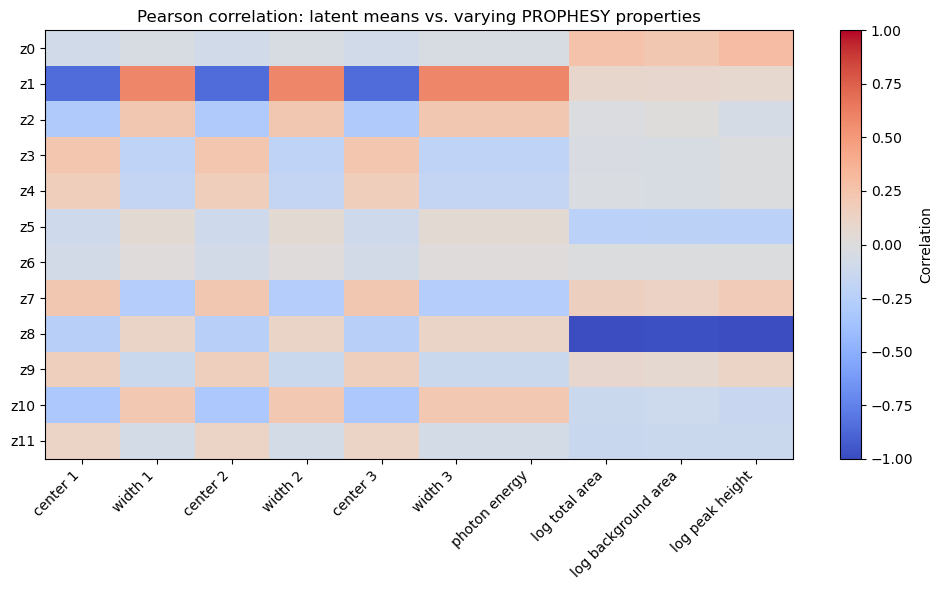

            center 1: z1 (r=-0.857)
             width 1: z1 (r=+0.584)
            center 2: z1 (r=-0.857)
             width 2: z1 (r=+0.584)
            center 3: z1 (r=-0.857)
             width 3: z1 (r=+0.584)
       photon energy: z1 (r=+0.584)
      log total area: z8 (r=-0.990)
 log background area: z8 (r=-0.982)
     log peak height: z8 (r=-0.985)


In [10]:
@torch.no_grad()
def encode_distributions(model, normalized_spectra, batch_size=1024):
    model.eval()
    means, log_variances = [], []
    for start in range(0, len(normalized_spectra), batch_size):
        x = torch.from_numpy(normalized_spectra[start:start + batch_size]).to(DEVICE)
        mu, logvar = model.encode(x)
        means.append(mu.cpu().numpy())
        log_variances.append(logvar.cpu().numpy())
    return np.concatenate(means), np.concatenate(log_variances)

def encode_means(model, normalized_spectra, batch_size=1024):
    means, _ = encode_distributions(model, normalized_spectra, batch_size)
    return means

z_test = encode_means(model, x_all[test_idx])
label_columns = {}
for i in range(3):
    label_columns[f"center {i + 1}"] = dataset["peak_center"][test_idx, i]
    label_columns[f"width {i + 1}"] = dataset["peak_width"][test_idx, i]
    label_columns[f"fraction {i + 1}"] = dataset["peak_fraction"][test_idx, i]
label_columns["photon energy"] = dataset["photon_energy"][test_idx]
label_columns["log total area"] = np.log1p(dataset["expected_total"][test_idx].sum(axis=1))
label_columns["log background area"] = np.log1p(dataset["background"][test_idx].sum(axis=1))
label_columns["log peak height"] = np.log1p(dataset["expected_total"][test_idx].max(axis=1))

physical_names_all = list(label_columns)
physical_all = np.column_stack([label_columns[name] for name in physical_names_all])
test_sources = dataset["source"][test_idx]
unique_test_sources = np.unique(test_sources)
z_by_source = []
physical_by_source = []
for source in unique_test_sources:
    mask = test_sources == source
    z_by_source.append(z_test[mask].mean(axis=0))
    physical_by_source.append(physical_all[mask].mean(axis=0))
z_by_source = np.asarray(z_by_source)
physical_by_source = np.asarray(physical_by_source)

varying = np.isfinite(physical_by_source).all(axis=0) & (np.ptp(physical_by_source, axis=0) > 1e-6)
excluded_names = [name for name, keep in zip(physical_names_all, varying) if not keep]
physical_names = [name for name, keep in zip(physical_names_all, varying) if keep]
physical = physical_by_source[:, varying]
print(f"Physical spectra used for correlation: {len(unique_test_sources)}")
print(f"Excluded constant/non-finite labels: {excluded_names or 'none'}")

correlation = np.empty((z_by_source.shape[1], physical.shape[1]), dtype=np.float64)
for i in range(z_by_source.shape[1]):
    for j in range(physical.shape[1]):
        correlation[i, j] = np.corrcoef(z_by_source[:, i], physical[:, j])[0, 1]

label_correlation = np.corrcoef(physical, rowvar=False)
for i in range(len(physical_names)):
    for j in range(i + 1, len(physical_names)):
        if abs(label_correlation[i, j]) >= 0.98:
            print(f"Collinear labels: {physical_names[i]} and {physical_names[j]} (r={label_correlation[i, j]:+.3f})")

fig, ax = plt.subplots(figsize=(max(10, 0.9 * len(physical_names)), 6))
image = ax.imshow(correlation, vmin=-1, vmax=1, cmap="coolwarm", aspect="auto")
ax.set_xticks(np.arange(len(physical_names)), physical_names, rotation=45, ha="right")
ax.set_yticks(np.arange(12), [f"z{i}" for i in range(12)])
ax.set_title("Pearson correlation: latent means vs. varying PROPHESY properties")
fig.colorbar(image, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()

for j, name in enumerate(physical_names):
    best = int(np.argmax(np.abs(correlation[:, j])))
    print(f"{name:>20}: z{best} (r={correlation[best, j]:+.3f})")

## Generate artificial spectra from the prior

These are unconditional samples from `z ~ N(0, I)`. Before plotting them, the cell reports the moments of the full aggregated posterior, using `Var(z) = Var(mu) + E[exp(logvar)]`. Comparing only the spread of encoder means with one is incorrect because it omits posterior sampling variance. Aggregate means near zero and full posterior standard deviations near one are necessary (but not sufficient) evidence of compatibility with the sampling prior. The separate spread of `mu` indicates which latent dimensions carry information; small values are expected for dimensions the model does not need.

Aggregated posterior mean:        [ 0.001 -0.008  0.    -0.     0.001  0.     0.    -0.001 -0.022 -0.001
  0.     0.002]
Aggregated posterior std:         [0.995 0.999 0.995 0.998 0.996 0.998 0.996 0.997 1.028 0.996 0.997 0.999]
Std of encoder means (activity): [0.01  0.903 0.029 0.02  0.018 0.026 0.008 0.019 1.026 0.024 0.016 0.015]
Informative latent dimensions:    [1, 8]
Largest |aggregate mean|=0.022; largest |aggregate std-1|=0.028


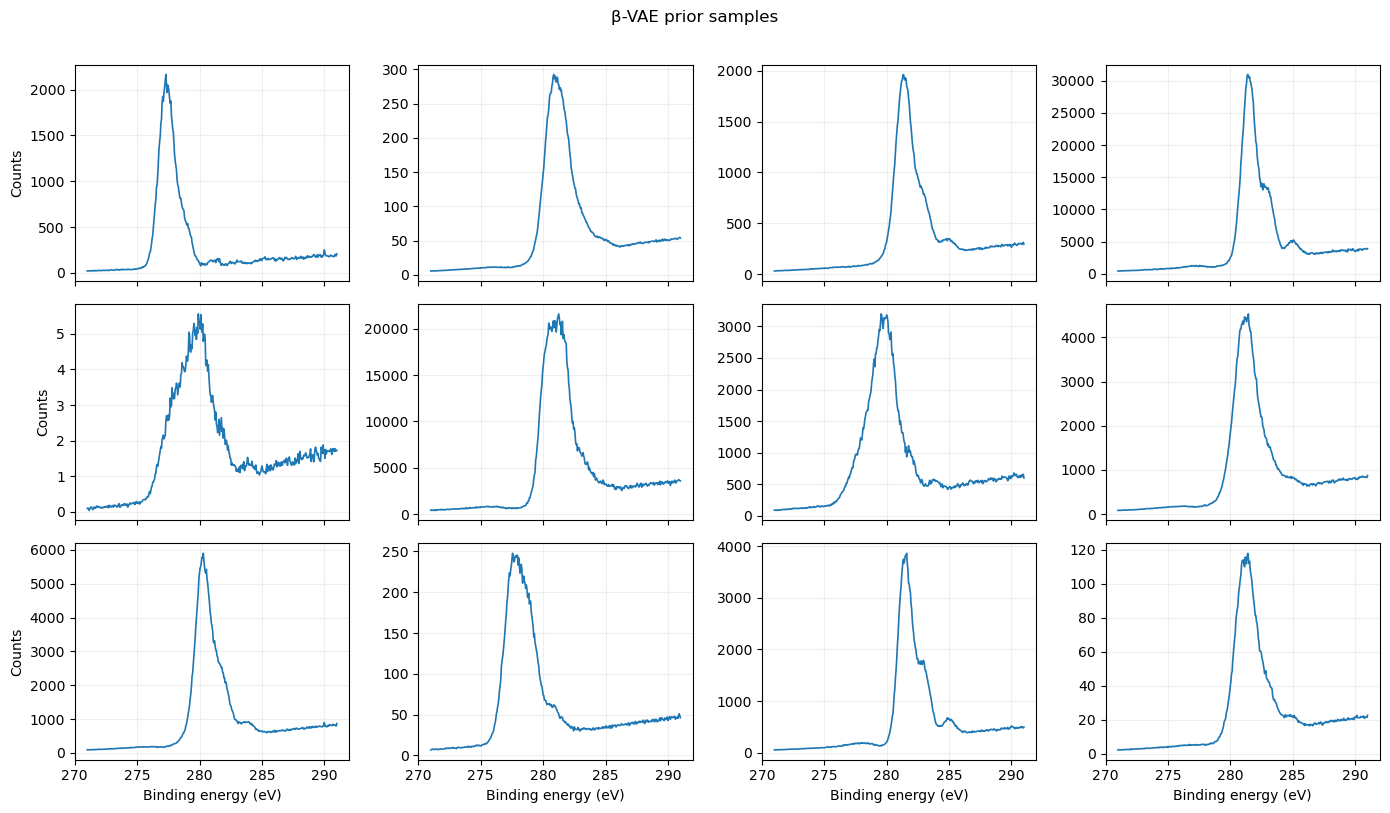

In [11]:
N_GENERATED = 12
train_latent_means, train_latent_logvars = encode_distributions(model, x_all[train_idx])
aggregate_mean = train_latent_means.mean(axis=0)
mean_std = train_latent_means.std(axis=0)
posterior_variance = np.exp(np.clip(train_latent_logvars, -30.0, 20.0)).mean(axis=0)
aggregate_variance = train_latent_means.var(axis=0) + posterior_variance
aggregate_std = np.sqrt(aggregate_variance)
informative_dimensions = np.flatnonzero(mean_std > 0.05)
print("Aggregated posterior mean:       ", np.round(aggregate_mean, 3))
print("Aggregated posterior std:        ", np.round(aggregate_std, 3))
print("Std of encoder means (activity):", np.round(mean_std, 3))
print("Informative latent dimensions:   ", informative_dimensions.tolist())
print(f"Largest |aggregate mean|={np.max(np.abs(aggregate_mean)):.3f}; "
      f"largest |aggregate std-1|={np.max(np.abs(aggregate_std - 1.0)):.3f}")

model.eval()
with torch.no_grad():
    z = torch.randn(N_GENERATED, 12, device=DEVICE)
    generated_normalized = model.decode(z).cpu().numpy()
generated_counts = denormalize_counts(generated_normalized)

fig, axes = plt.subplots(3, 4, figsize=(14, 8), sharex=True)
for ax, spectrum in zip(axes.flat, generated_counts):
    ax.plot(axis, spectrum, color="tab:blue", lw=1.2)
    ax.grid(alpha=0.2)
for ax in axes[-1]:
    ax.set_xlabel("Binding energy (eV)")
for ax in axes[:, 0]:
    ax.set_ylabel("Counts")
fig.suptitle("β-VAE prior samples", y=1.01)
plt.tight_layout()
plt.show()

## Interpretation and next checks

A successful run should show: (1) smooth reconstructions that retain the simulated C1s components without isolated one-bin spikes, (2) acceptable median and tail (p90/p95) raw-count errors against `Stot`, (3) similar validation and test metrics after the balanced group split, (4) no severe loss of accuracy in the weakest or strongest intensity quintiles, and (5) aggregate latent means near zero and full aggregated-posterior standard deviations near one before standard-normal prior samples are trusted.

The model architecture remains the paper-style fully connected β-VAE. Accuracy improvements come from the PROPHESY-specific training protocol: noise-free reconstruction targets, variance-stabilized counts, intensity-normalized shape losses, balanced physical-spectrum sampling, distribution-balanced group splits, robust log-area loss, deterministic validation, KL warm-up, adaptive learning rate, and raw-unit tail diagnostics. Constant or collinear simulation parameters still cannot become independently disentangled. In the current data, the three fractions remain fixed at 0.70/0.25/0.05 and peak centres and widths remain strongly coupled to photon energy; those limitations require new PROPHESY cases rather than another notebook-side adjustment.